# Hands-On 4: SVM and neural-network boundaries

Worked responses accompany the same experiments.

In [1]:
from pathlib import Path
import os
import sys
try:
    import mlcourse.setup
except ModuleNotFoundError:
    bases = [Path(os.environ.get("MLCOURSE_ROOT", Path.cwd())), Path.cwd(), Path("/content/pp-machine-learning")]
    for base in bases:
        for candidate in (base.resolve(), *base.resolve().parents):
            if (candidate / "src/mlcourse/setup.py").is_file():
                sys.path.insert(0, str(candidate / "src"))
                break
        else:
            continue
        break
    else:
        raise RuntimeError("Course files not found. Open the extracted course repository or set MLCOURSE_ROOT to its location.") from None

In [2]:
from mlcourse.setup import setup_notebook
REPO_ROOT = setup_notebook()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from mlcourse.labs import load_course_data

from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from mlcourse.labs import compare_boundaries, split_classification
from mlcourse.widgets import interactive_svm, interactive_mlp

## 1. Inspect the feature space

Load `ds1`, `ds2` and `ds3`. Use `ds2` for the subsequent experiments.

**Prediction:** Which geometries appear difficult for a single straight boundary?

Curved or interleaved regions should be difficult to separate using straight boundaries.

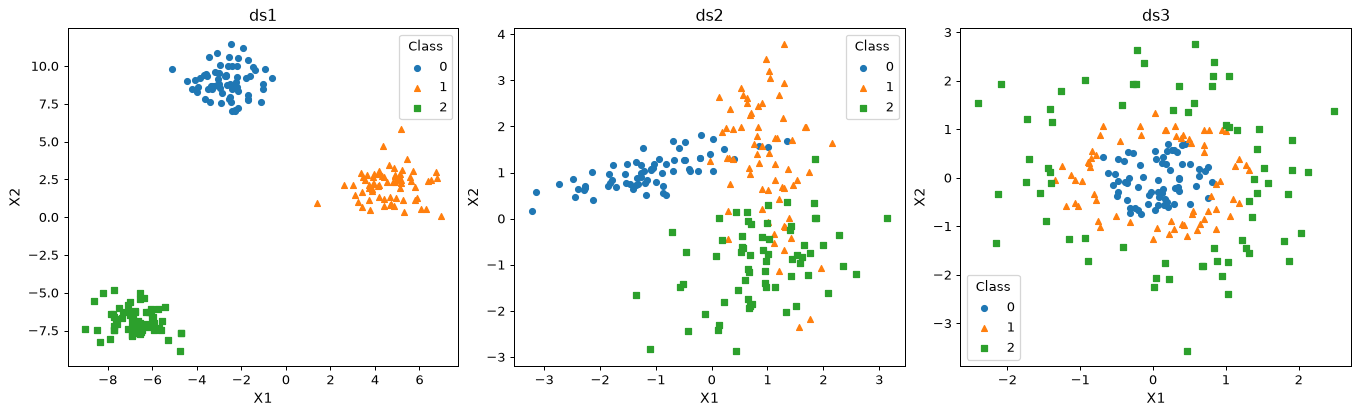

In [3]:
datasets = {name: load_course_data(name) for name in ['ds1', 'ds2', 'ds3']}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), layout='constrained')
for ax, (name, frame) in zip(axes, datasets.items()):
    for label, marker in zip(sorted(frame.Class.unique()), ['o', '^', 's']):
        part = frame[frame.Class == label]
        ax.scatter(part.X1, part.X2, label=str(label), marker=marker, s=22)
    ax.set(title=name, xlabel='X1', ylabel='X2')
    ax.legend(title='Class')
frame = datasets['ds2']
X_train, X_test, y_train, y_test = split_classification(frame[['X1', 'X2']], frame.Class)
plt.show()

**Observation:** Locate overlapping or curved class regions.

`ds1` has three well-separated groups; `ds2` has overlapping class regions. In `ds3`, a central group is surrounded by other classes, making a single straight separation unsuitable.

**Explanation:** How can feature-space geometry favour different inductive biases?

A model whose boundary family matches the geometry can represent the pattern with less complexity. Overlap can still produce errors even with a flexible boundary.

## 2. Compare three kernels

Fit linear, polynomial and RBF SVMs on the same split.

**Prediction:** Which kernels permit curved boundaries?

Polynomial and RBF kernels permit curved boundaries in the original two-feature space.

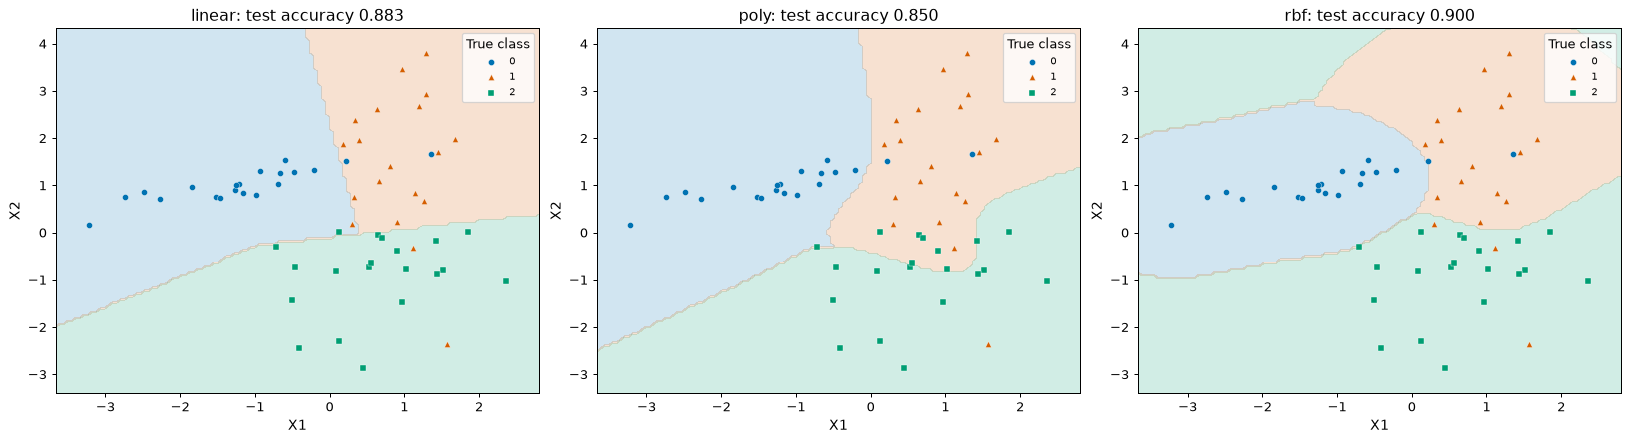

,train_accuracy,test_accuracy
model,,
linear,0.850,0.883
poly,0.850,0.850
rbf,0.871,0.900


In [4]:
display(compare_boundaries({kernel: make_pipeline(StandardScaler(), SVC(kernel=kernel, C=1, gamma=1, degree=3))
                           for kernel in ['linear', 'poly', 'rbf']}, X_train, X_test, y_train, y_test))

**Observation:** Compare boundary shapes and test accuracy.

The linear boundaries are straight, while polynomial and RBF boundaries bend. Their test accuracies are 0.883, 0.850 and 0.900 respectively.

**Explanation:** How does the kernel change the available boundary family?

The kernel defines similarity in a transformed feature space. A linear separator there can correspond to a nonlinear boundary in the displayed coordinates.

## 3. Manipulate the SVM

Change the kernel and its active controls. Compare small and large `C`; for RBF, change `gamma`.

**Prediction:** How might a larger RBF `gamma` change local sensitivity?

Larger `gamma` makes similarity decay more quickly with distance, allowing more local variation.

In [ ]:
svm_lab = interactive_svm(X_train, X_test, y_train, y_test)
display(svm_lab.widget)

**Observation:** Record one broad boundary and one more local boundary.

For RBF with `C=1`, `gamma=0.010` gives broad regions and training accuracy 0.829. At `gamma=10.000`, smaller local regions appear and training accuracy rises to 0.929; test accuracy remains 0.883 in both cases.

**Explanation:** Distinguish the effects of `C`, `gamma` and polynomial `degree`.

`C` changes the penalty on training errors relative to the margin objective. RBF `gamma` controls locality; polynomial `degree` changes the polynomial boundary family.

## 4. Fit a small neural network

Fit one hidden layer with five units and `activation="tanh"`.

**Prediction:** Can this network form a curved boundary?

Yes. Nonlinear hidden units can combine to form curved regions.

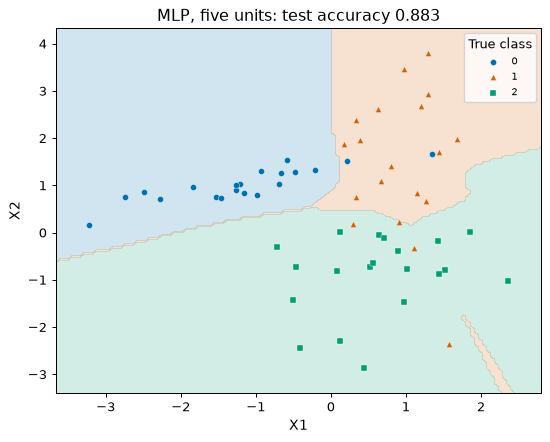

,train_accuracy,test_accuracy
model,,
"MLP, five units",0.886,0.883


In [6]:
display(compare_boundaries({'MLP, five units': make_pipeline(StandardScaler(),
    MLPClassifier(hidden_layer_sizes=(5,), activation='tanh', alpha=.01, solver='lbfgs',
                  max_iter=1500, tol=1e-3, random_state=0))}, X_train, X_test, y_train, y_test))

**Observation:** Compare its geometry with the kernel examples.

The five-unit network forms bent boundaries rather than the straight linear-SVM separators. Its test accuracy is 0.883, matching the linear SVM on this split despite the different geometry.

**Explanation:** Why does a nonlinear hidden layer change the boundary family?

Each hidden unit transforms a weighted combination of inputs. Combining nonlinear transformations allows a more flexible boundary than a single linear score.

## 5. Change capacity and initialisation

Vary hidden-layer width, count and activation. Then keep those fixed and change `random_state`.

**Prediction:** Should repeated initialisations produce exactly the same boundary?

Different initial weights can lead to different fitted boundaries even when architecture and data stay fixed.

In [ ]:
mlp_lab = interactive_mlp(X_train, X_test, y_train, y_test)
display(mlp_lab.widget)

**Observation:** Record one capacity change and one seed change.

With one tanh layer and `alpha=0.010`, increasing width from `5` to `20` changes train/test accuracy from 0.886/0.883 to 0.993/0.850. Keeping width `5` and changing seed from `0` to `1` gives the same rounded accuracies here; different initialisations need not change the aggregate score.

**Explanation:** Separate representational capacity, regularisation and optimisation variability.

Width and depth change which functions can be represented; `alpha` penalises large weights. The seed changes initialisation and can affect the fitted solution without changing the model family.